<a href="https://colab.research.google.com/github/mannduuu07-png/korea-fire-frequency-severity-analysis/blob/main/notebooks/05_excess_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 - Excess Risk Analysis

The strongest evidence in this project: for specific regions, does
their high casualty rate survive controlling for what *type* of
place their fires occur in (residential vs industrial vs commercial,
etc.)?

Baseline note: expected casualty rate for each target region is
computed from the national place-type distribution excluding that
region itself, to avoid the region's own extreme values inflating
its own benchmark.

In [10]:
import pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

df = pd.read_parquet('/content/drive/MyDrive/fire_data/processed/cleaned_fire_data.parquet')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
def region_stats_excl_worst(data, min_count=100):
    """지역별 화재건수 및 최악사건 제외 100건당피해자수 계산
    (03_frequency_vs_severity.ipynb와 동일 로직)"""
    result = []
    for (sido, sigungu), group in data.groupby(['시도', '시군구']):
        total_count = len(group)
        if total_count < min_count:
            continue
        total_casualty = group['인명피해(명)소계'].sum()
        worst_idx = group['인명피해(명)소계'].idxmax()
        worst_val = group.loc[worst_idx, '인명피해(명)소계']
        casualty_excl = total_casualty - worst_val
        result.append({
            '시도': sido, '시군구': sigungu, '화재건수': total_count,
            'casualties_per_100_excl': casualty_excl / (total_count - 1) * 100,
        })
    return pd.DataFrame(result)

In [12]:
def excess_risk_check(data, sido, sigungu):
    """Expected casualty rate = national per-place-type casualty rate
    (excluding the target region) weighted by the target region's own
    place-type mix. Compares this to the region's actual rate."""
    baseline = data[~((data['시도'] == sido) & (data['시군구'] == sigungu))]
    place_risk = baseline.groupby('장소대분류').agg(
        화재건수=('장소대분류', 'count'),
        인명피해합계=('인명피해(명)소계', 'sum'),
    )
    place_risk['casualty_rate'] = place_risk['인명피해합계'] / place_risk['화재건수']

    target = data[(data['시도'] == sido) & (data['시군구'] == sigungu)]
    mix = target['장소대분류'].value_counts(normalize=True)
    expected = (mix * place_risk['casualty_rate']).sum()
    actual = target['인명피해(명)소계'].mean()

    print(f"\n[{sido} {sigungu}]")
    print(f"  Place-type mix (top 3): {dict(mix.head(3).round(3))}")
    print(f"  Expected casualty rate (place-mix only): {expected:.4f}")
    print(f"  Actual casualty rate: {actual:.4f}")
    print(f"  Excess risk ratio: {actual/expected:.2f}x")
    return expected, actual

CHECK_TARGETS = [
    ('충청북도', '청주시상당구'),
    ('인천광역시', '남동구'),
    ('경상북도', '포항시북구'),
]
for sido, sigungu in CHECK_TARGETS:
    excess_risk_check(df, sido, sigungu)


[충청북도 청주시상당구]
  Place-type mix (top 3): {'주거': np.float64(0.327), '생활서비스': np.float64(0.135), '자동차,철도차량': np.float64(0.134)}
  Expected casualty rate (place-mix only): 0.0617
  Actual casualty rate: 0.1396
  Excess risk ratio: 2.26x

[인천광역시 남동구]
  Place-type mix (top 3): {'산업시설': np.float64(0.285), '주거': np.float64(0.234), '생활서비스': np.float64(0.129)}
  Expected casualty rate (place-mix only): 0.0610
  Actual casualty rate: 0.0922
  Excess risk ratio: 1.51x

[경상북도 포항시북구]
  Place-type mix (top 3): {'주거': np.float64(0.246), '기타': np.float64(0.176), '자동차,철도차량': np.float64(0.136)}
  Expected casualty rate (place-mix only): 0.0575
  Actual casualty rate: 0.1044
  Excess risk ratio: 1.82x


## Key findings

- **청주시상당구**: high-severity in both 2015-19 and 2020-24
  sub-periods, and shows a ~2.26x excess risk even after controlling
  for place-type composition. Not explained by a single mass-casualty
  event or by what kind of places its fires occur in.
- **인천 남동구**: emerged as high-severity only in 2020-2024. Its
  fires skew heavily industrial (2x national average), but even after
  accounting for that, actual casualties are ~1.51x the expected rate --
  place composition alone doesn't explain it either.

In [13]:
def excess_risk_check_silent_robust(data, sido, sigungu):
    """excess_risk_check_silent와 동일하나, actual 계산 시 해당 지역의
    최악사건 1건도 제외 (표본이 작은 지역에서 단일사건 왜곡 방지)"""
    baseline = data[~((data['시도'] == sido) & (data['시군구'] == sigungu))]
    place_risk = baseline.groupby('장소대분류').agg(
        화재건수=('장소대분류', 'count'),
        인명피해합계=('인명피해(명)소계', 'sum'),
    )
    place_risk['casualty_rate'] = place_risk['인명피해합계'] / place_risk['화재건수']

    target = data[(data['시도'] == sido) & (data['시군구'] == sigungu)]
    mix = target['장소대분류'].value_counts(normalize=True)
    expected = (mix * place_risk['casualty_rate']).sum()

    # 최악사건 1건 제외하고 actual 계산
    worst_idx = target['인명피해(명)소계'].idxmax()
    target_excl = target.drop(worst_idx)
    actual = target_excl['인명피해(명)소계'].mean()

    return expected, actual

# 300건 이상인 전체 지역에 대해 실행
region_300 = region_stats_excl_worst(df, min_count=300)

results = []
for _, row in region_300.iterrows():
    expected, actual = excess_risk_check_silent_robust(df, row['시도'], row['시군구'])
    results.append({
        '시도': row['시도'], '시군구': row['시군구'],
        '화재건수': row['화재건수'],
        'expected_casualty_rate': expected,
        'actual_casualty_rate': actual,
        'excess_risk_ratio': actual / expected,
    })

excess_df = pd.DataFrame(results)

In [14]:
# 초과위험배수 1.3배 이상만 우선관리 후보로 (기준은 조정 가능)
priority_regions = excess_df[excess_df['excess_risk_ratio'] >= 1.3].sort_values('excess_risk_ratio', ascending=False)
print(f"우선관리 후보지역: {len(priority_regions)}곳\n")
print(priority_regions[['시도','시군구','화재건수','expected_casualty_rate','actual_casualty_rate','excess_risk_ratio']].to_string(index=False))

priority_regions.to_csv('/content/drive/MyDrive/fire_data/processed/priority_regions.csv', index=False)

우선관리 후보지역: 21곳

     시도    시군구  화재건수  expected_casualty_rate  actual_casualty_rate  excess_risk_ratio
   경상북도  포항시북구  1743                0.057507              0.097589           1.696989
   충청북도    진천군  1133                0.056323              0.094523           1.678216
   충청북도    제천시  1041                0.059172              0.095192           1.608732
   충청북도 청주시상당구  1010                0.061749              0.098117           1.588960
   경상북도    울진군   770                0.056280              0.088427           1.571185
강원특별자치도    삼척시   930                0.049387              0.077503           1.569295
강원특별자치도    양양군   693                0.048040              0.070809           1.473972
강원특별자치도    원주시  3218                0.053304              0.077712           1.457906
    경기도 수원시팔달구  1017                0.065457              0.093504           1.428476
    경기도    과천시   438                0.056417              0.080092           1.419644
  인천광역시    남동구  2495                0.

In [15]:
gwacheon = df[(df['시도']=='경기도') & (df['시군구']=='과천시')]
print(gwacheon.nlargest(3, '인명피해(명)소계')[['화재발생년월일','인명피해(명)소계','장소대분류']])

                   화재발생년월일  인명피해(명)소계     장소대분류
366800 2022-12-29 13:49:00         52  자동차,철도차량
419    2024-01-05 14:29:00          2      산업시설
84053  2016-01-16 00:33:00          2     기타서비스


## Why the excess-risk calculation excludes each region's worst incident

과천시's initial excess risk ratio was 3.52x — but its single worst
incident (52 casualties, from a vehicle fire) accounts for the vast
majority of its total casualties, while its next-largest incident
caused only 2. This is the same distortion risk identified in
04_robustness_checks.ipynb, applied here to the excess-risk metric.
After excluding each region's worst incident, 과천시 drops to 1.42x
and 밀양시 (Sewoo Hospital fire, 190 casualties) drops out of the
priority list entirely — confirming both were single-event artifacts
rather than structural risk.

In [16]:
# 나눔고딕 폰트 설치 (Colab에서 한 번만 실행하면 됨)
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

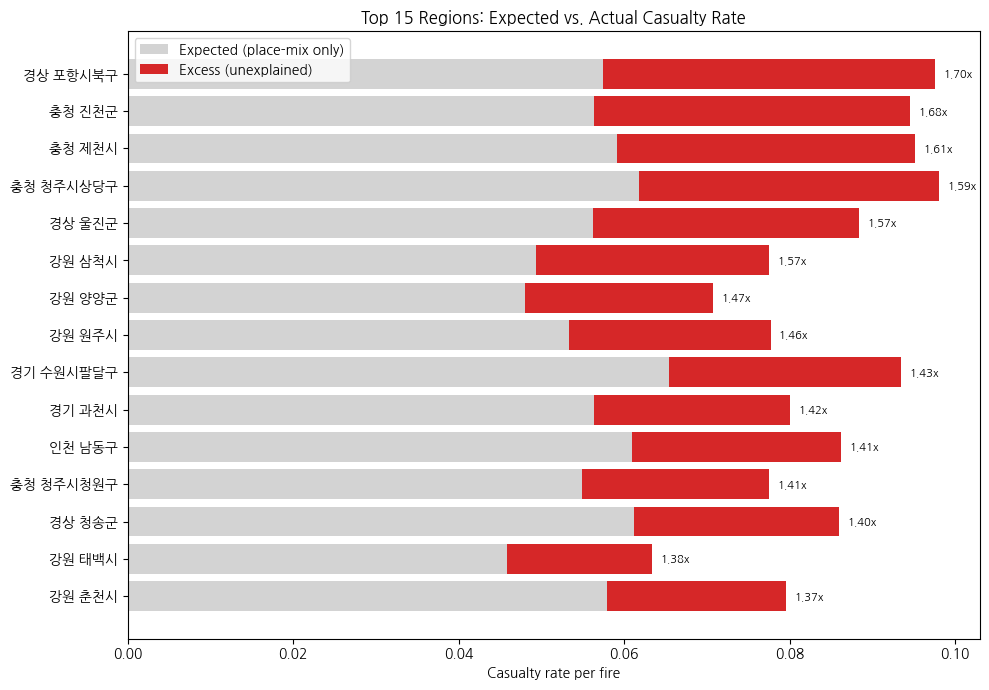

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')

top15 = priority_regions.head(15).copy()
top15['label'] = top15['시도'].str[:2] + ' ' + top15['시군구']

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(top15))
ax.barh(y, top15['expected_casualty_rate'], color='lightgray', label='Expected (place-mix only)')
ax.barh(y, top15['actual_casualty_rate'] - top15['expected_casualty_rate'],
        left=top15['expected_casualty_rate'], color='#d62728', label='Excess (unexplained)')
ax.set_yticks(y)
ax.set_yticklabels(top15['label'])
ax.invert_yaxis()
ax.set_xlabel('Casualty rate per fire')
ax.set_title('Top 15 Regions: Expected vs. Actual Casualty Rate')
ax.legend()
for i, (idx, row) in enumerate(top15.iterrows()):
    ax.text(row['actual_casualty_rate'] + 0.001, i, f"{row['excess_risk_ratio']:.2f}x",
            va='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fire_data/processed/expected_vs_actual.png', dpi=150)
plt.show()

   ## Priority regions

   21 regions show excess risk ≥1.3x even after excluding each region's
   single worst incident. 청주시상당구 is the strongest case, corroborated
   by persistence across both 2015-19 and 2020-24 sub-periods (see
   04_robustness_checks.ipynb) — the other 20 are flagged by this
   place-mix control alone and have not been cross-validated against
   time-period splits.